In [ ]:
 %%script echo skipping
 """
UrbanMining.ipynb
Detect urban settlement and mining in a single image
Calculate centroids of these categories and distance between them. Show on overlay image.

Problem: simiple arithmetic operations (NDBI) lump built environments and can not differentiate between urban settlement types (dense / sprawl / slum)
Solution: Supply sample areas, including negatives, to tune a simple classifier.
RTS with ChatGPT, November 2025

The script ingests a 10-band Sentinel-2 GeoTIFF and user-drawn scribbles for mining, urban, and background.
It builds spectral-texture features, trains simple centroid‑based binary classifiers (mining vs non-mining, urban vs non-urban)
using positive and negative samples. Morphology, NDVI/NDBI gates and distance constraints reduce false positives,
producing final mining/urban masks and centroids.
"""

skipping


In [ ]:
# variables specific to your CoLabsetup ----------------------------------------
from google.colab import drive
import sys

drive.mount('/content/drive')
root = '/content/drive/MyDrive/Colab/research/'
sys.path.append(root +"code/")

datapath = root + "data/"
ext_datapath = '/content/drive/MyDrive/Projects/Nudge-X/sites/'

#link to code directory
sys.path.append(root +'code/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


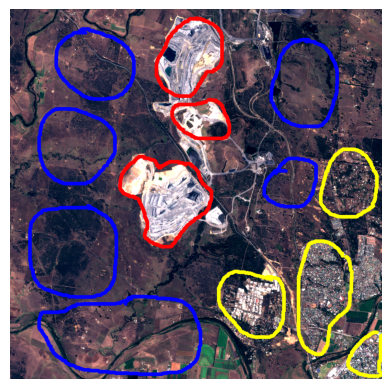

In [ ]:
# In addition to the multi-band (see below) geotif, supply an annoted rgb image of the same dimensions
image_filename = "RixCreekOpenCutMine_urban_mining_2024-12-29_rgb_outlines.png"
image_path = ext_datapath + image_filename
try:
    img = imageio.imread(image_path)
    plt.imshow(img); plt.axis('off'); plt.show()
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
 %%script echo skipping
"""
Urban / mining classifier using positive + negative scribble samples,
for a 10-band Sentinel-2 GeoTIFF (in this order):

    band 1: B02  (blue,  10 m)
    band 2: B03  (green, 10 m)
    band 3: B04  (red,   10 m)
    band 4: B05  (red-edge 1, 20 m resampled to 10 m)
    band 5: B06  (red-edge 2, 20 m -> 10 m)
    band 6: B07  (red-edge 3, 20 m -> 10 m)
    band 7: B08  (NIR broad, 10 m)
    band 8: B8A  (NIR narrow,20 m -> 10 m)
    band 9: B11  (SWIR1, 20 m -> 10 m)
    band10: B12  (SWIR2, 20 m -> 10 m)

Inputs
------
1) MULTIBAND_PATH : path to the 10-band GeoTIFF above
2) SAMPLES_PATH   : RGB image, same HxW as GeoTIFF, with scribbles:
       - mining : one or more colors in MINING_COLORS
       - urban  : one or more colors in URBAN_COLORS
       - neg    : one or more colors in NEGATIVE_COLORS
         (neg = "neither mining nor urban")

Outputs (OUT_PREFIX = MULTIBAND_PATH basename)
----------------------------------------------
- OUT_PREFIX_mining_mask.(tif|png)
- OUT_PREFIX_urban_mask.(tif|png)
- OUT_PREFIX_overlay.png   (NIR background, mining=red, urban=yellow)
"""

skipping


In [ ]:
%%capture
!pip install rasterio
import rasterio

In [ ]:
import os, math
import numpy as np
import rasterio
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

#helper functions
from urban_mining_helper import *

In [ ]:
 %%script echo skipping
'''
To reduce false positives:
- Increase MIN_PRECISION_MINING / MIN_PRECISION_URBAN (e.g. 0.9 / 0.9).
- Increase NEG_DILATE (wider exclusion around blue scribbles).
- Set MAX_DIST_PX_* to something like 200–300 to keep mine/urban near your scribbles.
- Tighten MINING_NDVI_MAX and URBAN_NDVI_MAX to strip vegetation.

If you start missing real mine/urban pixels:
- Lower the precision floors slightly.
- Reduce NEG_DILATE or MAX_DIST_PX_*.
- Relax the NDVI/NDBI gates.
'''

skipping


In [ ]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------

# 5-band Sentinel-2 stack
MULTIBAND = "RixCreekOpenCutMine_urban_mining_2024-12-29.tif"
MULTIBAND_PATH = ext_datapath + MULTIBAND

# RGB image with sample scribbles
version = "_rgb_outlines.png"
#ANNOTATION = MULTIBAND.split('_')[0] + '_' + MULTIBAND.split('_')[1] + MULTIBAND.split('_')[2] + '_' + (MULTIBAND.split('_')[3]).split('.tif')[0] + version
ANNOTATION = MULTIBAND.split('.tif')[0] + version
print(ANNOTATION)

SAMPLES_PATH = ext_datapath + ANNOTATION
OUT_PREFIX = os.path.splitext(MULTIBAND_PATH)[0]

# Colors for scribbles (you can add more examples)
# Each item is (R, G, B) in 0–255
MINING_COLORS = [
    (255,   0,   0),   # bright red
    # (r2, g2, b2),    # add more mining colors if needed
]

URBAN_COLORS = [
    (255, 255,   0),   # bright yellow
    # (r2, g2, b2),    # add more urban colors if needed
]

NEGATIVE_COLORS = [
    (  0, 0,  255),    # e.g. blue - choose whatever you draw as "background"
]

# Tolerance in RGB space (L1 distance) when matching scribble colors
COLOR_TOL = 25

# Limit negative training pixels per classifier (for speed)
MAX_NEG_TRAIN = 50000

# Min area (px) for final connected components
MINING_MIN_AREA =  2000
URBAN_MIN_AREA  =   800   #500

# Precision floors for threshold search (per class)
# Higher min precision: fewer false positives
MIN_PRECISION_MINING = 0.85
MIN_PRECISION_URBAN  = 0.80

# Negative exclusion radius (pixels) around blue scribbles
NEG_DILATE = 3    # 0 = only exact blue pixels; >0 = wider moat

# Optional max distance from scribbles (pixels); None = no limit
MAX_DIST_PX_MINING = 300           #None    # e.g. 250
MAX_DIST_PX_URBAN  = 300           #None    # e.g. 250

# Optional simple spectral gates
# If the yellow spill is mostly on bushy / scrubby areas, lowering URBAN_NDVI_MAX is effective
USE_SPECTRAL_GATES = True
MINING_NDVI_MAX = 0.45
MINING_NDBI_MIN = 0.00
URBAN_NDVI_MAX  = 0.50   #0.7


RixCreekOpenCutMine_urban_mining_2024-12-29_rgb_outlines.png


In [ ]:
def main():
    if not os.path.exists(MULTIBAND_PATH):
        raise SystemExit(f"GeoTIFF not found: {MULTIBAND_PATH}")
    if not os.path.exists(SAMPLES_PATH):
        raise SystemExit(f"Sample image not found: {SAMPLES_PATH}")

    # 1) Load Sentinel-2 10-band stack
    with rasterio.open(MULTIBAND_PATH) as src:
        arr = src.read().astype(np.float32)
        profile = src.profile

    if arr.shape[0] != 10:
        raise SystemExit("Expected 10 bands (B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12).")

    (blue, green, red,
     b05, b06, b07,
     nir, b8a,
     b11, b12) = arr
    H_tif, W_tif = blue.shape

    # 2) Load scribble image and align/crop
    samples_rgb = imageio.imread(SAMPLES_PATH)
    if samples_rgb.ndim == 2:
        raise SystemExit("Sample image must be RGB, not grayscale.")
    H_s, W_s = samples_rgb.shape[:2]

    H = min(H_tif, H_s)
    W = min(W_tif, W_s)

    blue, green, red, b05, b06, b07, nir, b8a, b11, b12 = [b[:H, :W] for b in (blue, green, red, b05, b06, b07, nir, b8a, b11, b12)]
    samples_rgb = samples_rgb[:H, :W, :3]
    profile.update(height=H, width=W)

    # 3) Features from 10 bands
    scale = 10000.0
    blue  = np.clip(blue  / scale, 0, 1)
    green = np.clip(green / scale, 0, 1)
    red   = np.clip(red   / scale, 0, 1)
    re1   = np.clip(b05   / scale, 0, 1)
    re2   = np.clip(b06   / scale, 0, 1)
    re3   = np.clip(b07   / scale, 0, 1)
    nir   = np.clip(nir   / scale, 0, 1)
    nir_n = np.clip(b8a   / scale, 0, 1)
    swir1 = np.clip(b11   / scale, 0, 1)
    swir2 = np.clip(b12   / scale, 0, 1)

    eps = 1e-6
    ndvi   = (nir   - red)   / (nir   + red   + eps)
    ndre2  = (nir   - re2)   / (nir   + re2   + eps)
    ndwi   = (green - nir)   / (green + nir   + eps)
    ndbi12 = (swir2 - nir)   / (swir2 + nir   + eps)
    ndbi11 = (swir1 - nir)   / (swir1 + nir   + eps)
    ndmi11 = (nir   - swir1) / (nir   + swir1 + eps)
    ndmi12 = (nir   - swir2) / (nir   + swir2 + eps)
    bsi    = ((swir2 + red) - (nir + blue)) / ((swir2 + red) + (nir + blue) + eps)

    red01   = contrast_stretch(red)
    green01 = contrast_stretch(green)
    blue01  = contrast_stretch(blue)
    nir01   = contrast_stretch(nir)
    nir_n01 = contrast_stretch(nir_n)
    re201   = contrast_stretch(re2)
    swir1_01= contrast_stretch(swir1)
    swir2_01= contrast_stretch(swir2)

    vis01   = (red01 + green01 + blue01) / 3.0
    B_nir   = (nir01 + nir_n01) / 2.0
    B_swir  = (swir1_01 + swir2_01) / 2.0

    hf_vis  = hi_freq_std(vis01, sigma=1.0, win=5)

    feat_stack = np.stack([
        blue, green, red,
        re1, re2, re3,
        nir, nir_n,
        swir1, swir2,
        ndvi, ndre2,
        ndbi11, ndbi12,
        ndmi11, ndmi12,
        ndwi, bsi,
        vis01, B_nir, B_swir,
        hf_vis,
    ], axis=-1)           # (H, W, D)

    H, W, D = feat_stack.shape
    X_all = feat_stack.reshape(-1, D)
    valid = np.all(np.isfinite(X_all), axis=1)

    # 4) Extract sample masks (mining, urban, negative)
    mining_sample, urban_sample, neg_sample = extract_masks_from_colors(
        samples_rgb,[MINING_COLORS, URBAN_COLORS, NEGATIVE_COLORS],COLOR_TOL)

    print("Sample pixels – mining:", int(mining_sample.sum()),
          "urban:", int(urban_sample.sum()),
          "negative:", int(neg_sample.sum()))

    if mining_sample.sum() < 50 or urban_sample.sum() < 50 or neg_sample.sum() < 50:
        raise SystemExit("Need at least ~50 pixels for each of mining, urban, and negative samples.")

    mine_flat  = mining_sample.ravel()
    urban_flat = urban_sample.ravel()
    neg_flat   = neg_sample.ravel()

    # 5) Train mining classifier (pos = mining, neg = urban + negative)
    X_m_pos = X_all[mine_flat & valid]
    neg_for_m = (urban_flat | neg_flat) & valid
    neg_idx_all = np.where(neg_for_m)[0]
    rng = np.random.default_rng(42)

    if neg_idx_all.size > MAX_NEG_TRAIN:
        neg_idx = rng.choice(neg_idx_all, size=MAX_NEG_TRAIN, replace=False)
    else:
        neg_idx = neg_idx_all

    X_m_neg = X_all[neg_idx]

    print("Training mining classifier...")
    print("  pos samples:", X_m_pos.shape[0], "neg samples:", X_m_neg.shape[0])
    mu_m, sig_m, c_m_pos, c_m_neg, thr_m = train_binary_centroid_classifier(
        X_m_pos, X_m_neg, min_precision=MIN_PRECISION_MINING)

    # 6) Train urban classifier (pos = urban, neg = mining + negative)
    X_u_pos = X_all[urban_flat & valid]
    neg_for_u = (mine_flat | neg_flat) & valid
    neg_u_idx_all = np.where(neg_for_u)[0]

    if neg_u_idx_all.size > MAX_NEG_TRAIN:
        neg_u_idx = rng.choice(neg_u_idx_all, size=MAX_NEG_TRAIN, replace=False)
    else:
        neg_u_idx = neg_u_idx_all

    X_u_neg = X_all[neg_u_idx]

    print("Training urban classifier...")
    print("  pos samples:", X_u_pos.shape[0], "neg samples:", X_u_neg.shape[0])
    mu_u, sig_u, c_u_pos, c_u_neg, thr_u = train_binary_centroid_classifier(
        X_u_pos, X_u_neg, min_precision=MIN_PRECISION_URBAN
    )

    # 7) Apply classifiers to all pixels
    print("Applying classifiers to full image...")
    mine_pred_flat  = apply_binary_centroid_classifier(
        X_all, mu_m, sig_m, c_m_pos, c_m_neg, thr_m)

    urban_pred_flat = apply_binary_centroid_classifier(
        X_all, mu_u, sig_u, c_u_pos, c_u_neg, thr_u)

    mine_pred  = mine_pred_flat.reshape(H, W) & valid.reshape(H, W)
    urban_pred = urban_pred_flat.reshape(H, W) & valid.reshape(H, W)

    # remove obvious water from both
    water_like = (ndwi > 0.25) & (B_swir < 0.5)
    mine_pred[water_like]  = False
    urban_pred[water_like] = False

    # resolve overlaps
    both = mine_pred & urban_pred
    only_m = mine_pred & ~urban_pred
    only_u = urban_pred & ~mine_pred

    mine_mask  = only_m.copy()
    urban_mask = only_u.copy()

    # where both true, pick the classifier with smaller distance to its centroid
    d_m_all = np.sum(((X_all - mu_m) / sig_m - c_m_pos) ** 2, axis=1)
    d_u_all = np.sum(((X_all - mu_u) / sig_u - c_u_pos) ** 2, axis=1)
    d_m_img = d_m_all.reshape(H, W)
    d_u_img = d_u_all.reshape(H, W)
    mine_mask[both & (d_m_img <  d_u_img)] = True
    urban_mask[both & (d_u_img <= d_m_img)] = True

    # always include explicit samples
    mine_mask |= mining_sample
    urban_mask |= urban_sample
    urban_mask &= ~mine_mask

    # Optional spectral gates
    if USE_SPECTRAL_GATES:
        mine_mask  &= (ndvi <= MINING_NDVI_MAX) & (ndbi12 >= MINING_NDBI_MIN)
        urban_mask &= (ndvi <= URBAN_NDVI_MAX)

    # 8) Morphological cleanup (first pass)
    mine_mask  = cleanup_min_area(mine_mask,  MINING_MIN_AREA, open_iter=1, close_iter=1)
    urban_mask = cleanup_min_area(urban_mask, URBAN_MIN_AREA, open_iter=1, close_iter=1)

    # 9) Negative scribbles as local veto (cut holes, not whole components)
    if NEG_DILATE > 0:
        neg_forced = ndi.binary_dilation(neg_sample, iterations=NEG_DILATE)
    else:
        neg_forced = neg_sample

    mine_mask  &= ~neg_forced
    urban_mask &= ~neg_forced

    # 10) Optional max-distance from scribbles
    if MAX_DIST_PX_MINING is not None:
        dist_m = ndi.distance_transform_edt(~mining_sample)
        mine_mask &= (dist_m <= MAX_DIST_PX_MINING)

    if MAX_DIST_PX_URBAN is not None:
        dist_u = ndi.distance_transform_edt(~urban_sample)
        urban_mask &= (dist_u <= MAX_DIST_PX_URBAN)

    # 11) Restrict to components that actually touch scribbles
    mine_mask  = keep_components_touching_seed(mine_mask,  mining_sample, MINING_MIN_AREA)
    urban_mask = keep_components_touching_seed(urban_mask, urban_sample,  URBAN_MIN_AREA)

    # 12) Final cleanup
    mine_mask  = cleanup_min_area(mine_mask,  MINING_MIN_AREA, open_iter=1, close_iter=1)
    urban_mask = cleanup_min_area(urban_mask, URBAN_MIN_AREA, open_iter=1, close_iter=1)

    print("Final mining pixels:", int(mine_mask.sum()))
    print("Final urban pixels :", int(urban_mask.sum()))
    print("Extra mining pixels outside samples:", int((mine_mask & ~mining_sample).sum()))
    print("Extra urban pixels outside samples :", int((urban_mask & ~urban_sample).sum()))

    #13) Centroids
    transform = profile.get("transform", None)
    crs = profile.get("crs", None)

    # Global centroids
    cx_m_px, cy_m_px, x_m, y_m = centroid_from_mask(mine_mask,  transform)
    cx_u_px, cy_u_px, x_u, y_u = centroid_from_mask(urban_mask, transform)

    if x_m is None or x_u is None:
        print("Centroids: cannot compute distance – one of the masks is empty.")
        dist_global = None
    else:
        dx = x_u - x_m
        dy = y_u - y_m
        dist_global = math.hypot(dx, dy)

        units = "map units"
        if crs is not None and crs.is_projected:
            units = "meters"

        print(f"Mining centroid (map x,y): {x_m:.2f}, {y_m:.2f}")
        print(f"Urban  centroid (map x,y): {x_u:.2f}, {y_u:.2f}")
        print(f"Distance between mining and urban centroids: {dist_global:.2f} {units}")

    # Component-wise centroids
    mine_centers  = component_centroids(mine_mask,  transform)
    urban_centers = component_centroids(urban_mask, transform)

    print("\nComponent centroids:")
    print(f"  Mining components: {len(mine_centers)}")
    print(f"  Urban  components: {len(urban_centers)}")

    # distance from each mining centroid to its nearest urban centroid
    if mine_centers and urban_centers and (mine_centers[0][2] is not None):
        for i, (cx_m, cy_m, x_mi, y_mi) in enumerate(mine_centers):
            dists = [
                np.sqrt((x_mi - x_ui) ** 2 + (y_mi - y_ui) ** 2)
                for (_, _, x_ui, y_ui) in urban_centers
            ]
            d_min = float(np.min(dists)) if dists else float("nan")
            print(f"  Mine #{i+1} at ({x_mi:.1f},{y_mi:.1f}) – "
                  f"nearest urban centroid: {d_min:.1f} map units away")
    else:
        print("Not enough centroids to compute per-component distances.")

    # 14) Save masks
    #write_mask_tif(f"{OUT_PREFIX}_mining_mask.tif", mine_mask, profile)
    #write_mask_tif(f"{OUT_PREFIX}_urban_mask.tif",  urban_mask, profile)
    #imageio.imwrite(f"{OUT_PREFIX}_mining_mask.png", (mine_mask.astype(np.uint8) * 255))
    #imageio.imwrite(f"{OUT_PREFIX}_urban_mask.png", (urban_mask.astype(np.uint8) * 255))

    # 15) Overlay
    base = contrast_stretch(nir)  # NIR as grayscale background
    base_rgb = np.stack([base, base, base], axis=-1)
    class_rgb = np.zeros_like(base_rgb)
    class_rgb[mine_mask]  = (1.0, 0.0, 0.0)   # mining: red
    class_rgb[urban_mask] = (1.0, 1.0, 0.0)   # urban : yellow
    alpha = np.where(class_rgb.sum(axis=2) > 0, 0.55, 0.0)[..., None]
    overlay = base_rgb * (1 - alpha) + class_rgb * alpha

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.title("Mining (red) and urban (yellow)")
    plt.axis("off")

    # draw centroids + line if both exist
    if cx_m_px is not None and cy_m_px is not None and cx_u_px is not None and cy_u_px is not None:
        # mark the centroids
        plt.scatter([cx_m_px], [cy_m_px], marker="x", s=80, c="cyan",   label="mine centroid")
        plt.scatter([cx_u_px], [cy_u_px], marker="x", s=80, c="magenta", label="urban centroid")
        # line between mining and urban centroids
        plt.plot([cx_m_px, cx_u_px], [cy_m_px, cy_u_px], linestyle="--", linewidth=2, color="white")

        #plt.legend(loc="upper right", fontsize=8)

    plt.title("Mining (red) and urban (yellow)")
    plt.axis("off")
    plt.savefig(f"{OUT_PREFIX}_overlay.png", dpi=200, bbox_inches="tight", pad_inches=0)
    plt.show()

    # 16) Save
    print("Saved:")
    #print("  ", f"{OUT_PREFIX}_mining_mask.(tif|png)")
    #print("  ", f"{OUT_PREFIX}_urban_mask.(tif|png)")
    print("  ", f"{OUT_PREFIX}_overlay.png")

Sample pixels – mining: 88646 urban: 95349 negative: 264506
Training mining classifier...
  pos samples: 88646 neg samples: 50000
Training urban classifier...
  pos samples: 95349 neg samples: 50000
Applying classifiers to full image...
Final mining pixels: 78596
Final urban pixels : 113263
Extra mining pixels outside samples: 10871
Extra urban pixels outside samples : 48510
Mining centroid (map x,y): 323482.31, 6401772.65
Urban  centroid (map x,y): 327178.24, 6398141.28
Distance between mining and urban centroids: 5181.38 meters

Component centroids:
  Mining components: 3
  Urban  components: 2
  Mine #1 at (323816.6,6403372.1) – nearest urban centroid: 6077.9 map units away
  Mine #2 at (323048.2,6400098.5) – nearest urban centroid: 4456.0 map units away
  Mine #3 at (324484.2,6399534.2) – nearest urban centroid: 2916.1 map units away


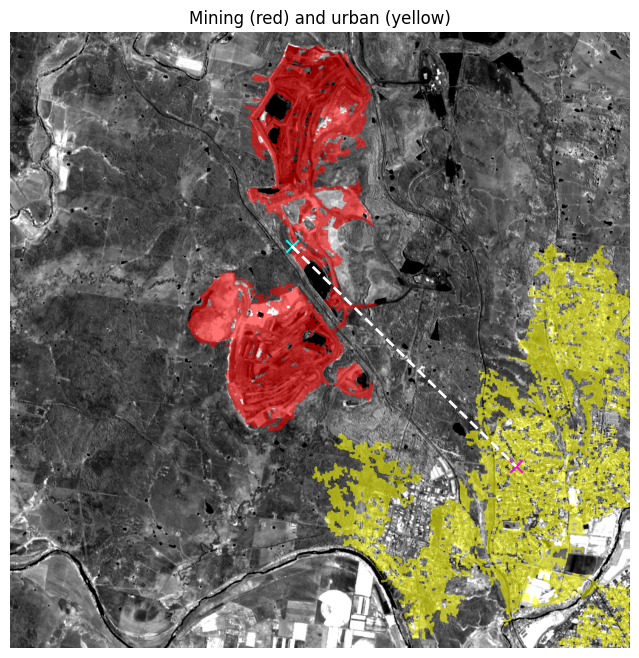

Saved:
   /content/drive/MyDrive/Projects/Nudge-X/sites/RixCreekOpenCutMine_urban_mining_2024-12-29_overlay.png


In [ ]:
if __name__ == "__main__":
    main()